# 노트북 00c — 수학 툴박스

ML-KEM을 따라가는 데 꼭 필요한 수학만 다룹니다. 추상 그 자체를 위한 내용은 없습니다.

In [1]:
import numpy as np


## Modular arithmetic

`a mod q`는 `a`를 `q`로 나눈 나머지입니다. 이 책 전체에서 q = 3329 (ML-KEM의 소수) 를 사용합니다. 모든 산술은 `{0, 1, ..., q-1}` 집합 안에서 일어납니다.

In [2]:
q = 3329
print((5 + 3329) % q)        # 5
print((-1) % q)              # 3328  (note: Python's % returns non-negative)
print((2 * 1665) % q)        # 1  — 1665 is the multiplicative inverse of 2 mod 3329


5
3328
1


**왜 소수 q인가?** q가 소수이면 0이 아닌 *모든* 원소가 곱셈 역원을 가집니다. 이로써 Z_q는 **체 (field)** 가 됩니다 — 덧셈, 뺄셈, 곱셈, 나눗셈(= 역원 곱) 이 모두 가능합니다. ML-KEM은 이에 의존합니다: q가 소수가 아니면 NTT (노트북 04) 가 동작하지 않습니다.

In [3]:
# Modular inverse via Fermat's little theorem: a^(q-1) ≡ 1 (mod q), so a^(q-2) = a^-1.
a = 17
a_inv = pow(a, -1, q)   # Python's built-in since 3.8
print(f"{a} * {a_inv} mod {q} = {(a * a_inv) % q}")   # 1


17 * 1175 mod 3329 = 1


## mod q의 벡터와 행렬

우리는 `Z_q^n` 의 벡터 (길이 n인 mod q 정수 벡터) 와 그런 벡터들로 이루어진 `k×k` 행렬을 계속 사용합니다. 모든 연산 — 내적, 행렬 곱 — 은 q를 법으로 하여 수행됩니다.

In [4]:
n = 4
rng = np.random.default_rng(0)
a = rng.integers(0, q, n); s = rng.integers(0, q, n)
inner = int(a @ s) % q
print("a =", a)
print("s =", s)
print("<a, s> mod q =", inner)

A = rng.integers(0, q, (3, 3))
v = rng.integers(0, q, 3)
print("\nA =\n", A)
print("A @ v mod q =", (A @ v) % q)


a = [2831 2120 1701  898]
s = [1024  136  250   55]
<a, s> mod q = 4

A =
 [[ 583 2707 2161]
 [3038 1676 2019]
 [3231 2428 2104]]
A @ v mod q = [2841  654 1242]


## 군, 환, 체 — 30초 요약

- **Group (덧셈군)**: 항등원(0) 과 역원을 가진 덧셈 연산이 정의된 집합. `Z_q`와 `+ mod q`는 group입니다.
- **Ring (환)**: group에 덧셈에 대해 분배되는 곱셈이 추가된 구조. `Z_q`와 `+, ×`는 ring입니다.
- **Field (체)**: 0이 아닌 모든 원소가 곱셈 역원을 가지는 ring. *소수* q에 대한 `Z_q`는 field입니다.
- ML-KEM은 `R_q = Z_q[x] / (x^n + 1)` 에서 동작합니다 — 계수가 `Z_q`에 속하고 `x^n + 1`로 나눈 polynomial들. 이는 ring입니다 (field가 아님). 노트북 04에서 자세히 다룹니다.

## Hash function과 PRF

- **Hash function**: 결정적이며, 고정 크기 출력, 충돌 저항성을 가집니다. `H(x)`는 "fingerprint"를 제공합니다. 예: SHA-256.
- **XOF (extendable-output function)**: hash와 비슷하지만 출력 길이를 가변적으로 할 수 있습니다. ML-KEM은 SHAKE-128과 SHAKE-256을 사용합니다.
- **PRF (pseudo-random function)**: 키가 있는 함수 `PRF(key, x)` 로, 키를 모르는 사람 입장에서 출력이 랜덤과 구별 불가능합니다. ML-KEM에서는 비밀로 seed된 SHAKE-256이 PRF 역할을 합니다.

In [5]:
import hashlib
print("SHA3-256('hello') =", hashlib.sha3_256(b"hello").hexdigest())

# SHAKE-256 — variable length
h = hashlib.shake_256(); h.update(b"seed")
print("SHAKE-256 64-byte output =", h.digest(64).hex())

# Same seed → same output (deterministic)
h2 = hashlib.shake_256(); h2.update(b"seed")
print("deterministic:", h.digest(64) == h2.digest(64))


SHA3-256('hello') = 3338be694f50c5f338814986cdf0686453a888b84f424d792af4b9202398f392
SHAKE-256 64-byte output = 4fd6800b5ddf65323de29f59e5da90d3fa6778594e60e2ff4326622eff3e42c4ffb0cbd6d1735223365916ac2d97eb47b86c1573d1e640ff4f4020d805e01cd8
deterministic: True


## Discrete Gaussian / 작은 잡음

Lattice 암호는 비밀을 숨기기 위해 "작은" 잡음을 더합니다. 0 근처에 집중된 분포에서 샘플링합니다:

- **Discrete Gaussian**: `N(0, σ²)` 에서 샘플링 후 정수로 반올림합니다. 이론적으로 좋지만, 상수 시간으로 구현하기가 살짝 까다롭습니다.
- **Centered Binomial Distribution (CBD)**: ML-KEM의 실용적 선택입니다. 독립적인 η 번의 동전 던지기로 `a`, `b`를 각각 뽑고 `a - b`를 출력합니다. 범위: `{-η, ..., η}`, 평균 0, 대칭, 샘플링이 쉽습니다.

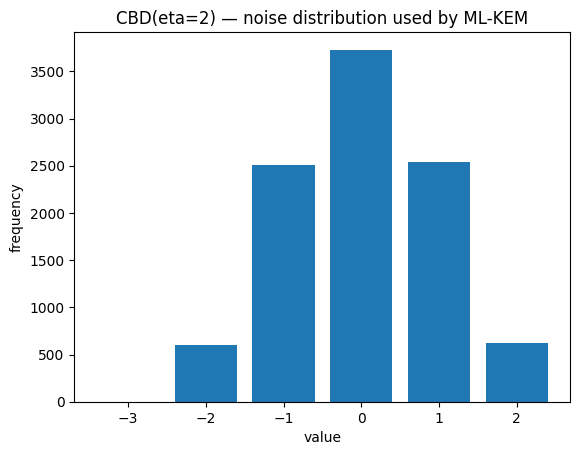

In [6]:
rng = np.random.default_rng(0)
# CBD with eta=2: two pairs of coin flips, difference gives values in {-2, ..., 2}
eta = 2
samples = rng.integers(0, 2, (10000, 2 * eta)).sum(axis=1)
cbd = samples[:5000] - rng.integers(0, 2, (5000, 2 * eta)).sum(axis=1)
# Simpler: directly
a = rng.integers(0, 2, (10000, eta)).sum(axis=1)
b = rng.integers(0, 2, (10000, eta)).sum(axis=1)
cbd = a - b

import matplotlib.pyplot as plt
plt.hist(cbd, bins=range(-eta-1, eta+2), rwidth=0.8, align="left")
plt.title(f"CBD(eta={eta}) — noise distribution used by ML-KEM")
plt.xlabel("value"); plt.ylabel("frequency")
plt.show()


## 지금까지 얻은 것

- `a ≡ b (mod q)`, `<a, s>`, `A·s + e`, `H(x)`, `PRF(k, n)` 을 코드로 읽을 수 있습니다.
- 왜 q가 소수인지 (역원 때문), CBD가 어떻게 생겼는지 알게 되었습니다.
- 책 전체에 필요한 수학 어휘는 이것이 전부입니다.

→ `01_lattice_intro`.